# Laboratorio 7.1 — Análisis visual y cuantitativo de correlaciones

## Analítica de Datos

En el Laboratorio 7 estudiamos cómo explorar relaciones entre variables y utilizamos el coeficiente de correlación de Pearson para cuantificar relaciones lineales.

En este laboratorio complementario trabajaremos con un **conjunto de datos real sobre automóviles** para observar con mayor claridad cómo se manifiestan diferentes relaciones entre variables numéricas.

### Objetivos

Al finalizar el laboratorio podremos:

- explorar relaciones entre variables numéricas mediante diagramas de dispersión;
- identificar visualmente la dirección de una relación;
- calcular el coeficiente de correlación de Pearson;
- interpretar el signo y la magnitud de una correlación;
- comparar relaciones de diferente intensidad;
- reconocer la importancia de complementar el coeficiente de correlación con la exploración visual de los datos.

## 1. Conjunto de datos: Auto MPG

En este laboratorio utilizaremos el conjunto de datos **Auto MPG**, que contiene información sobre diferentes características de automóviles.

El archivo utilizado en este laboratorio es:

**`auto-mpg.csv`**

Una vez cargado en Google Colab, estará disponible en la ruta:

`/content/auto-mpg.csv`
Fuente de Kaggle: https://www.kaggle.com/datasets/uciml/autompg-dataset?resource=download

Entre las variables disponibles se encuentran:

- `mpg`: rendimiento de combustible del vehículo;
- `cylinders`: número de cilindros;
- `displacement`: cilindrada del motor;
- `horsepower`: potencia del motor;
- `weight`: peso del vehículo;
- `acceleration`: aceleración;
- `model_year`: año del modelo;
- `origin`: origen del vehículo.

El conjunto de datos nos permitirá estudiar si algunas características de los vehículos presentan relaciones lineales entre sí.

## 2. Preparación del entorno

Importaremos las bibliotecas necesarias para cargar, explorar y visualizar los datos.

Utilizaremos:

- `pandas` para manipular el conjunto de datos;
- `matplotlib` para construir gráficos;
- `seaborn` para representar las relaciones entre variables.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 3. Carga del conjunto de datos

Cargaremos el archivo `auto-mpg.csv` utilizando `pandas`.

En Google Colab el archivo se encuentra en la ruta:

`/content/auto-mpg.csv`

Después de cargarlo, visualizaremos las primeras observaciones para verificar su estructura y reconocer las variables disponibles.

In [3]:
df = pd.read_csv("/content/auto-mpg.csv")
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


## 4. Inspección inicial de los datos
Antes de analizar relaciones entre variables, verificaremos brevemente la estructura del conjunto de datos.
Revisaremos:
- número de filas y columnas;
- tipos de datos;
- presencia de valores faltantes.
Esta revisión es importante porque una variable que contiene datos faltantes o que no fue reconocida como numérica puede afectar los análisis posteriores.

In [4]:
print("Dimensiones del dataset:", df.shape)
print("\nTipos de datos:")
print(df.dtypes)
print("\nValores faltantes:")
print(df.isnull().sum())

Dimensiones del dataset: (398, 9)

Tipos de datos:
mpg             float64
cylinders         int64
displacement    float64
horsepower       object
weight            int64
acceleration    float64
model year        int64
origin            int64
car name         object
dtype: object

Valores faltantes:
mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtype: int64


## 5. Revisión de la variable `horsepower`

La inspección inicial muestra que la variable `horsepower` fue reconocida por `pandas` como tipo `object`, mientras que las demás características cuantitativas fueron reconocidas como variables numéricas.

Antes de utilizar `horsepower` en un análisis de correlación, debemos investigar por qué esta columna no fue interpretada como numérica.

Primero examinaremos los valores que contiene la variable.

In [5]:
df["horsepower"].unique()

array(['130', '165', '150', '140', '198', '220', '215', '225', '190',
       '170', '160', '95', '97', '85', '88', '46', '87', '90', '113',
       '200', '210', '193', '?', '100', '105', '175', '153', '180', '110',
       '72', '86', '70', '76', '65', '69', '60', '80', '54', '208', '155',
       '112', '92', '145', '137', '158', '167', '94', '107', '230', '49',
       '75', '91', '122', '67', '83', '78', '52', '61', '93', '148',
       '129', '96', '71', '98', '115', '53', '81', '79', '120', '152',
       '102', '108', '68', '58', '149', '89', '63', '48', '66', '139',
       '103', '125', '133', '138', '135', '142', '77', '62', '132', '84',
       '64', '74', '116', '82'], dtype=object)

### Investigue la variable `horsepower`
Al observar los valores únicos de `horsepower`, encontramos que la columna contiene valores numéricos almacenados como texto y también el símbolo `?`.
Responda:

1. ¿Por qué `pandas` reconoció la variable `horsepower` como tipo `object`?
2. ¿Qué podría representar el símbolo `?` dentro de esta variable?
3. ¿Por qué estos registros no fueron detectados como valores faltantes mediante `isnull()`?
4. ¿Podemos calcular directamente una correlación de Pearson utilizando `horsepower` en su estado actual?

In [6]:
df["horsepower"] = pd.to_numeric(
    df["horsepower"],
    errors="coerce"
)
print("Tipo de dato:", df["horsepower"].dtype)
print("Valores faltantes:", df["horsepower"].isnull().sum())

Tipo de dato: float64
Valores faltantes: 6


## 6. Tratamiento de los valores faltantes

Después de convertir `horsepower` a una variable numérica identificamos **6 valores faltantes de un total de 398 observaciones**, aproximadamente el **1,5 %** del conjunto de datos.

Para este laboratorio no estimaremos ni reemplazaremos estos valores.

Cuando un análisis involucre la variable `horsepower`, utilizaremos únicamente las observaciones que contienen información disponible para esta variable.

> **Importante:** las observaciones no serán eliminadas del DataFrame original `df`. Crearemos un conjunto de datos auxiliar únicamente para los análisis que involucren `horsepower`.

In [7]:
df_horsepower = df.dropna(subset=["horsepower"])
print("Observaciones originales:", len(df))
print("Observaciones disponibles:", len(df_horsepower))
print("Observaciones excluidas:", len(df) - len(df_horsepower))

Observaciones originales: 398
Observaciones disponibles: 392
Observaciones excluidas: 6


## 7. Exploración visual de una relación entre variables numéricas

Comenzaremos analizando dos características de los vehículos:

- `weight`: peso del vehículo.
- `mpg`: rendimiento de combustible medido en millas por galón.

Antes de calcular cualquier coeficiente de correlación, construiremos un **diagrama de dispersión**.

### Pregunta de análisis

**¿Existe algún patrón entre el peso de un vehículo y su rendimiento de combustible?**

Observe especialmente:

- la dirección general de los puntos;
- qué ocurre con `mpg` a medida que aumenta `weight`;
- qué tan claramente se aprecia el patrón.

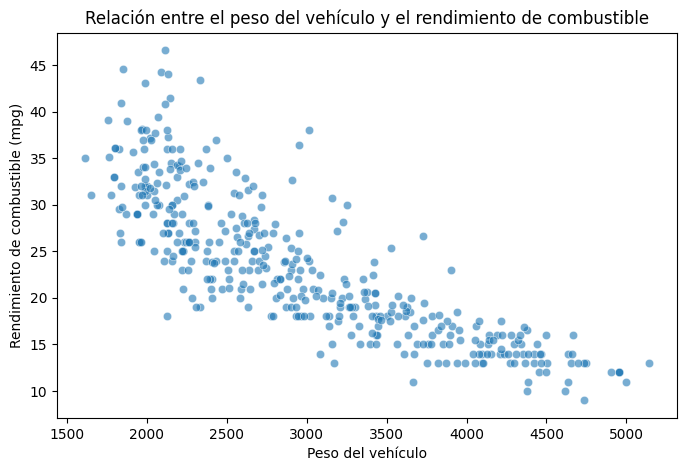

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x="weight",
    y="mpg",
    alpha=0.6
)
plt.title("Relación entre el peso del vehículo y el rendimiento de combustible")
plt.xlabel("Peso del vehículo")
plt.ylabel("Rendimiento de combustible (mpg)")
plt.show()

### Interprete el diagrama de dispersión
Observe el comportamiento de los puntos en el gráfico y responda:
1. ¿Se observa un patrón entre `weight` y `mpg`?
2. ¿La relación observada es positiva o negativa?
3. ¿Qué ocurre generalmente con el rendimiento de combustible (`mpg`) a medida que aumenta el peso del vehículo?
4. ¿La relación observada parece débil, moderada o fuerte?
5. A partir del gráfico, ¿qué signo esperaría encontrar en el coeficiente de correlación de Pearson?

## 8. Cuantificación de la relación

El diagrama de dispersión muestra una tendencia negativa entre `weight` y `mpg`.

Ahora utilizaremos el **coeficiente de correlación de Pearson** para cuantificar la dirección y la intensidad de esta relación lineal.

Posteriormente compararemos el valor obtenido con la interpretación realizada a partir del gráfico.

In [8]:
correlacion_weight_mpg = df["weight"].corr(df["mpg"])
print("Correlación entre weight y mpg:")
print(correlacion_weight_mpg)

Correlación entre weight y mpg:
-0.8317409332443352


### Interprete el coeficiente de correlación

El coeficiente de correlación de Pearson obtenido entre `weight` y `mpg` fue aproximadamente:

**r = -0.832**

Responda:

1. ¿Qué indica el signo negativo del coeficiente?
2. ¿Cómo clasificaría la intensidad de la relación lineal observada?
3. ¿El resultado obtenido coincide con el patrón observado previamente en el diagrama de dispersión?
4. ¿Qué podemos afirmar sobre el comportamiento de `mpg` cuando aumenta `weight`?
5. ¿Este resultado permite afirmar que un mayor peso es, por sí solo, la causa de un menor rendimiento de combustible?

## 9. Exploración de una relación positiva

Hasta ahora analizamos una relación negativa fuerte entre `weight` y `mpg`.

Ahora estudiaremos dos variables diferentes:

- `displacement`: cilindrada del motor.
- `weight`: peso del vehículo.

### Pregunta de análisis

**¿Existe algún patrón entre la cilindrada del motor y el peso del vehículo?**

Antes de calcular el coeficiente de correlación, observe el diagrama de dispersión e identifique:

- la dirección de la relación;
- la intensidad aparente del patrón;
- qué ocurre con `weight` a medida que aumenta `displacement`.

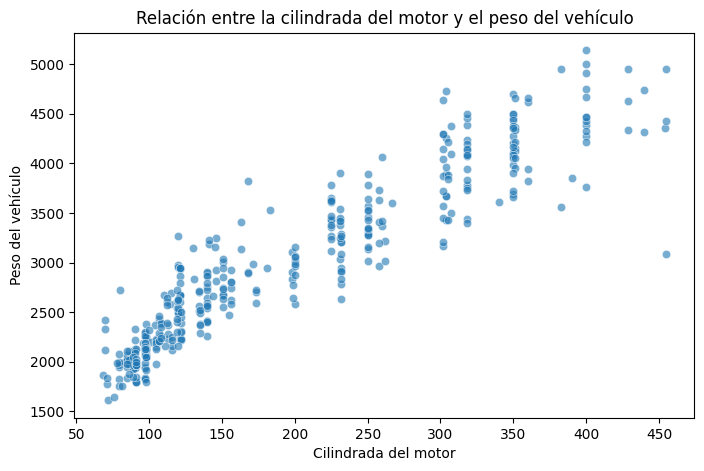

In [9]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x="displacement",
    y="weight",
    alpha=0.6
)
plt.title("Relación entre la cilindrada del motor y el peso del vehículo")
plt.xlabel("Cilindrada del motor")
plt.ylabel("Peso del vehículo")
plt.show()

### Interprete el diagrama de dispersión

Observe la relación entre `displacement` y `weight` y responda:

1. ¿Se observa un patrón entre las dos variables?
2. ¿La relación observada es positiva o negativa?
3. ¿Qué ocurre generalmente con el peso del vehículo a medida que aumenta la cilindrada del motor?
4. ¿La relación parece débil, moderada o fuerte?
5. A partir del gráfico, ¿qué signo esperaría encontrar en el coeficiente de correlación de Pearson?

## 10. Cuantificación de la relación positiva

El diagrama de dispersión sugiere una relación positiva entre `displacement` y `weight`.

Calcularemos el coeficiente de correlación de Pearson para determinar la dirección y la intensidad de esta relación lineal y comparar el resultado con nuestra interpretación visual.

In [10]:
correlacion_displacement_weight = df["displacement"].corr(df["weight"])
print("Correlación entre displacement y weight:")
print(correlacion_displacement_weight)

Correlación entre displacement y weight:
0.9328241468416342


### Interprete el coeficiente de correlación

El coeficiente de correlación de Pearson obtenido entre `displacement` y `weight` fue aproximadamente:
**r = 0.933**
Responda:

1. ¿Qué indica el signo positivo del coeficiente?
2. ¿Cómo clasificaría la intensidad de la relación lineal?
3. ¿El resultado coincide con lo observado previamente en el diagrama de dispersión?
4. ¿Qué podemos afirmar sobre el comportamiento de `weight` cuando aumenta `displacement`?
5. Compare este resultado con la correlación obtenida anteriormente entre `weight` y `mpg` (**r = -0.832**). ¿Cuál presenta una relación lineal de mayor intensidad?

In [ ]:
variables_numericas = [
    "mpg",
    "cylinders",
    "displacement",
    "horsepower",
    "weight",
    "acceleration"
]
df[variables_numericas].corr()

,mpg,cylinders,displacement,horsepower,weight,acceleration
mpg,1.000000,-0.775396,-0.804203,-0.778427,-0.831741,0.420289
cylinders,-0.775396,1.000000,0.950721,0.842983,0.896017,-0.505419
displacement,-0.804203,0.950721,1.000000,0.897257,0.932824,-0.543684
horsepower,-0.778427,0.842983,0.897257,1.000000,0.864538,-0.689196
weight,-0.831741,0.896017,0.932824,0.864538,1.000000,-0.417457
acceleration,0.420289,-0.505419,-0.543684,-0.689196,-0.417457,1.000000


### Interprete la matriz de correlaciones

La matriz permite comparar simultáneamente las relaciones lineales entre varias características de los vehículos.

Observe los coeficientes y responda:

1. Sin considerar la diagonal principal, ¿qué pareja de variables presenta la correlación positiva más fuerte?
2. ¿Qué pareja presenta la correlación negativa más fuerte?
3. ¿Cuál de las relaciones mostradas presenta el coeficiente más cercano a cero?
4. ¿Todas las variables presentan relaciones lineales de la misma intensidad?
5. ¿Por qué los valores de la diagonal principal son iguales a 1?

## 12. Visualización de la matriz de correlaciones

La matriz anterior permite conocer el coeficiente de correlación de Pearson para cada pareja de variables.

Sin embargo, cuando aumenta el número de variables, comparar todos los coeficientes directamente en una tabla puede resultar difícil.

Una forma de facilitar su interpretación es mediante un **mapa de calor (heatmap)**, que representa visualmente la matriz de correlaciones.

En el gráfico:

- cada celda representa la correlación entre dos variables;
- el valor numérico indica el coeficiente de Pearson;
- la intensidad visual permite identificar rápidamente relaciones de diferente magnitud.

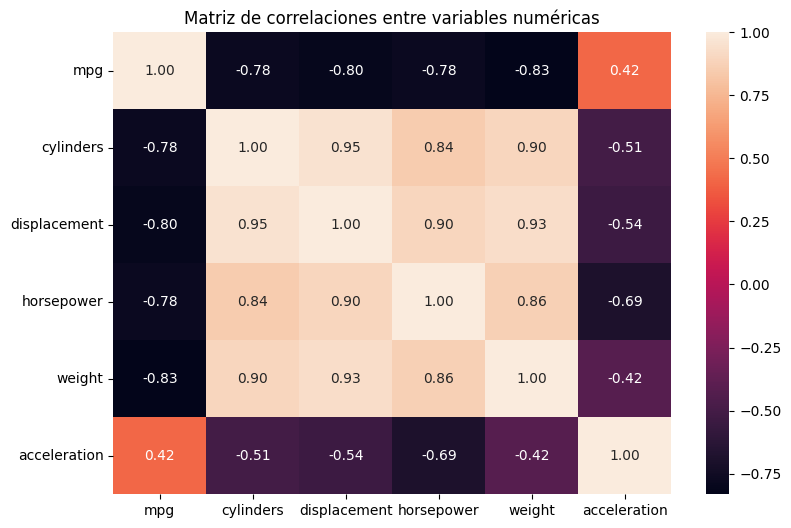

In [ ]:
matriz_correlacion = df[variables_numericas].corr()

plt.figure(figsize=(9, 6))

sns.heatmap(
    matriz_correlacion,
    annot=True,
    fmt=".2f"
)

plt.title("Matriz de correlaciones entre variables numéricas")
plt.show()

### Interprete el mapa de calor

Observe el mapa de calor y responda:

1. ¿Qué ventaja ofrece el mapa de calor frente a observar únicamente la matriz numérica?
2. ¿Qué variables presentan la relación lineal positiva más fuerte?
3. ¿Qué variables presentan la relación lineal negativa más fuerte?
4. ¿Qué representa un coeficiente cercano a 1? ¿Y uno cercano a -1?
5. ¿Podemos utilizar el color de una celda sin consultar el valor del coeficiente para determinar exactamente la intensidad de una relación?

## 13. Cierre del Laboratorio 7.1

En este laboratorio utilizamos un conjunto de datos real para estudiar relaciones entre variables numéricas.

A partir de los resultados obtenidos, responda:

1. ¿Por qué conviene observar un diagrama de dispersión antes de interpretar un coeficiente de correlación?
2. ¿Qué diferencia existe entre una correlación positiva y una negativa?
3. ¿Qué información aporta la magnitud del coeficiente de Pearson?
4. ¿Qué ventaja proporciona una matriz de correlaciones cuando analizamos varias variables?
5. ¿Una correlación fuerte permite afirmar que una variable causa los cambios observados en otra?